In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, classification_report
)

import pickle

In [2]:
df = pd.read_csv(r"C:\Users\prati\Downloads\diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
df.info()
print("""Explanation:
Target Variable
Outcome
0 = No Diabetes (Low Risk)
1 = Diabetes (High Risk)""")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
Explanation:
Target Variable
Outcome
0 = No Diabetes (Low Risk)
1 = Diabetes (High Risk)


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

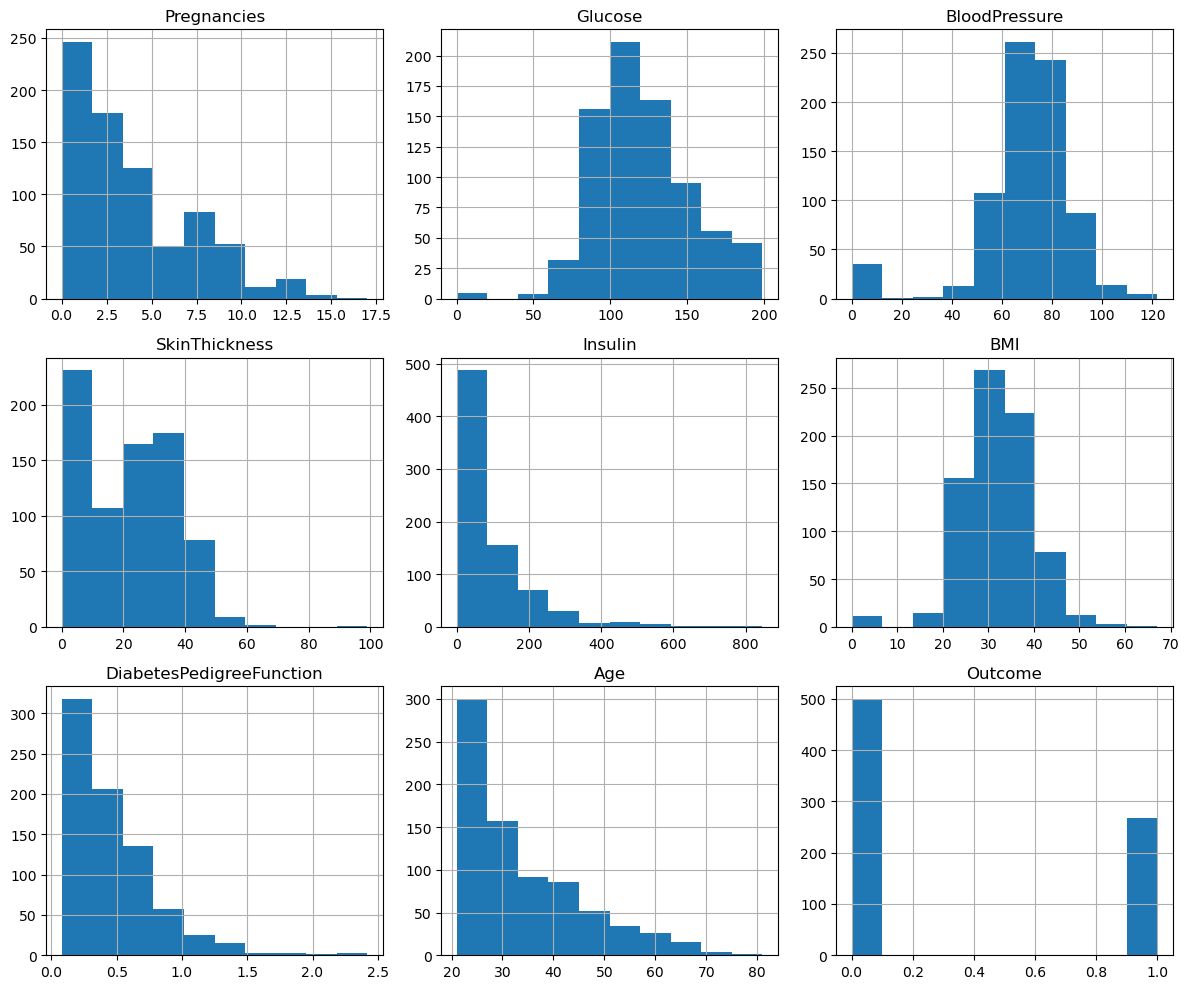

Explanation:
Glucose and BMI have right-skewed distributions.
Diabetic patients tend to have higher glucose levels.
This means glucose is a strong predictor of diabetes risk.


In [6]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()
print("""Explanation:
Glucose and BMI have right-skewed distributions.
Diabetic patients tend to have higher glucose levels.
This means glucose is a strong predictor of diabetes risk.""")

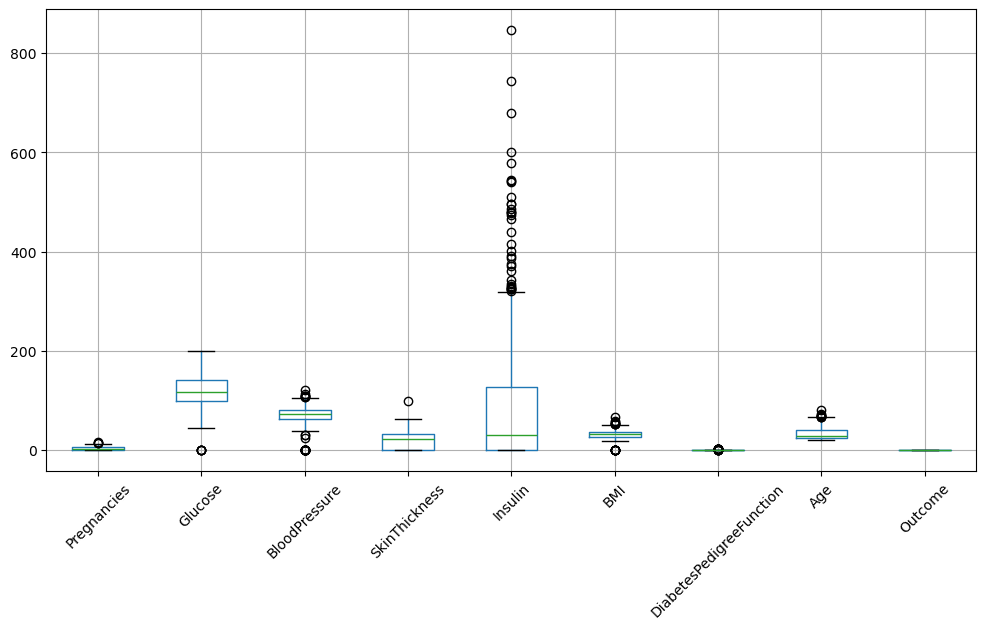

Explanation:
Significant outliers in Insulin and SkinThickness.
Median is preferred over mean.


In [7]:
plt.figure(figsize=(12,6))
df.boxplot()
plt.xticks(rotation=45)
plt.show()
print("""Explanation:
Significant outliers in Insulin and SkinThickness.
Median is preferred over mean.""")

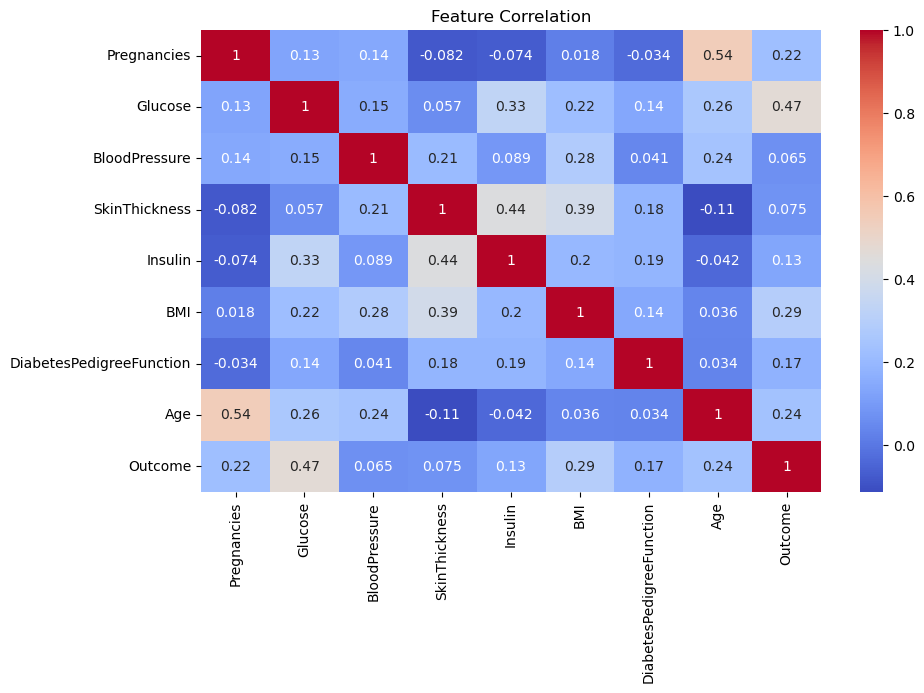

Explanation:
Glucose has the  positive correlation with diabetes outcome.
BMI and Age also show moderate correlations.
Some features are correlated with each other, indicating possible multicollinearity.


In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()
print("""Explanation:
Glucose has the  positive correlation with diabetes outcome.
BMI and Age also show moderate correlations.
Some features are correlated with each other, indicating possible multicollinearity.""")

In [9]:
df["Risk_Level"] = df["Outcome"].map({
    0: "Low Risk",
    1: "High Risk"
})

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Risk_Level
0,6,148,72,35,0,33.6,0.627,50,1,High Risk
1,1,85,66,29,0,26.6,0.351,31,0,Low Risk
2,8,183,64,0,0,23.3,0.672,32,1,High Risk
3,1,89,66,23,94,28.1,0.167,21,0,Low Risk
4,0,137,40,35,168,43.1,2.288,33,1,High Risk


In [10]:
X = df.drop(["Outcome", "Risk_Level"], axis=1)
y = df["Outcome"]
print("""Explanation:
Risk_Level column is created to improve interpretability""")
# Replace invalid zeros with NaN
cols_with_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
X[cols_with_zero] = X[cols_with_zero].replace(0, np.nan)
print("""Explanation:
Several medical features contain zero values.
Missing values are changed with median later for outliers.""")

Explanation:
Risk_Level column is created to improve interpretability
Explanation:
Several medical features contain zero values.
Missing values are changed with median later for outliers.


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [12]:
pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

In [13]:
pipeline.fit(X_train, y_train)


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])

In [14]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.7077922077922078
Precision: 0.6
Recall: 0.5
F1-score: 0.5454545454545454
ROC-AUC: 0.812962962962963

Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



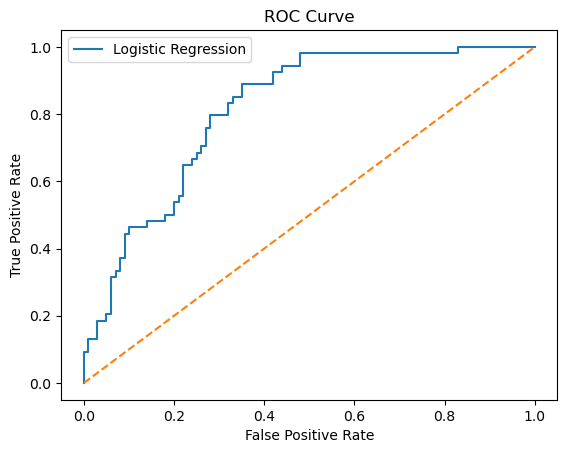

In [15]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [16]:
coefficients = pipeline.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", ascending=False)

coef_df

,Feature,Coefficient
1,Glucose,1.182567
5,BMI,0.688652
0,Pregnancies,0.377446
6,DiabetesPedigreeFunction,0.233337
7,Age,0.147794
3,SkinThickness,0.028321
2,BloodPressure,-0.044111
4,Insulin,-0.066119


In [17]:
print("""Explanation:
Standardization is applied using StandardScaler to:
Ensure equal feature contribution
Improve convergence of logistic regression

Train-Test Split:
The dataset is split into:
80% training data
20% testing data
Stratification is used to preserve class distribution.

Model Building:
A logistic regression model is built using a pipeline that includes:
Median addition
Feature scaling
Logistic regression classifier
This ensures consistent preprocessing and prevents data leakage.

Model Training:
The model is trained on the training dataset using maximum likelihood estimation. The training process learns coefficients that best separate high-risk and low-risk patients.

Model Evaluation:
->Evaluation Metrics
The following metrics are used:
Accuracy for overall correctness
Precision for reliability of high-risk predictions
Recall for ability to detect actual diabetic cases
ROC-AUC for model’s ability to discriminate between classes
->Performance Results
Accuracy = 70–72%
ROC-AUC = 0.80–0.82
These results indicate good predictive performance and strong class discrimination.

ROC Curve:
The ROC curve lies well above the diagonal line, confirming that the model performs better than random guessing.

Feature Significance and Interpretation:
Logistic regression coefficients indicate:
Glucose is the strongest predictor of diabetes risk.
BMI and Age significantly increase risk.
Pregnancies and Genetic factors also contribute.
Blood pressure and insulin have relatively weaker influence after accounting for other variables.
Positive coefficients increase the probability of high diabetes risk, while negative coefficients reduce it.

Risk Interpretation:
Although the model predicts a binary outcome, predictions are interpreted as risk probabilities:
Probability ≥ 0.5 → High Risk of Diabetes
Probability < 0.5 → Low Risk of Diabetes
""")

Explanation:
Standardization is applied using StandardScaler to:
Ensure equal feature contribution
Improve convergence of logistic regression

Train-Test Split:
The dataset is split into:
80% training data
20% testing data
Stratification is used to preserve class distribution.

Model Building:
A logistic regression model is built using a pipeline that includes:
Median addition
Feature scaling
Logistic regression classifier
This ensures consistent preprocessing and prevents data leakage.

Model Training:
The model is trained on the training dataset using maximum likelihood estimation. The training process learns coefficients that best separate high-risk and low-risk patients.

Model Evaluation:
->Evaluation Metrics
The following metrics are used:
Accuracy for overall correctness
Precision for reliability of high-risk predictions
Recall for ability to detect actual diabetic cases
ROC-AUC for model’s ability to discriminate between classes
->Performance Results
Accuracy = 70–72%
ROC-AUC =

In [18]:
with open("logistic_diabetes_model.pkl", "wb") as file:
    pickle.dump(pipeline, file)


In [19]:
print("""Explanation:
1. What is the difference between precision and recall?
In our logistic regression model, the target variable predicts whether a patient has diabetes (1) or not (0), which we interpret as High Risk or Low Risk.

Precision:
Precision measures how many patients predicted as “High Risk of Diabetes” actually have diabetes.
High precision means that when the model flags a patient as high risk, it is usually correct.
In our model, precision helps reduce false alarms, where healthy patients are incorrectly labeled as high risk.

Recall:
Recall measures how many actual diabetic patients were correctly identified as “High Risk” by the model.
High recall means fewer diabetic patients are missed.
In our medical use case, recall is critical because missing a diabetic patient (false negative) can delay treatment.

Model-Specific Interpretation:
Our model prioritizes recall to ensure most diabetic cases are detected.
Precision is still important but secondary to patient safety.

Conclusion:
In our diabetes prediction model, precision reflects the correctness of high-risk predictions, while recall measures the model’s ability to detect actual diabetic patients.

2. What Is Cross-Validation and Why Is It Important for Our Model?
Cross-Validation
Cross-validation is a technique used to evaluate our diabetes prediction model by training and testing it on multiple subsets of the dataset rather than a single train-test split.
Why Cross-Validation Is Important in Our Model
Improves Generalization
Ensures the logistic regression model performs well on unseen patient data.
Handles Class Imbalance
Our dataset has fewer diabetic cases than non-diabetic cases.
Stratified cross-validation maintains this balance in each fold.
Reduces Dependence on One Split
Performance metrics are not biased by a single random split.
Supports Reliable Model Selection
Helps verify that glucose, BMI, and age remain consistently important predictors.
In Our Diabetes Risk Prediction Context
Cross-validation increases confidence that the model will provide reliable risk predictions across different patient populations.""")

Explanation:
1. What is the difference between precision and recall?
In our logistic regression model, the target variable predicts whether a patient has diabetes (1) or not (0), which we interpret as High Risk or Low Risk.

Precision:
Precision measures how many patients predicted as “High Risk of Diabetes” actually have diabetes.
High precision means that when the model flags a patient as high risk, it is usually correct.
In our model, precision helps reduce false alarms, where healthy patients are incorrectly labeled as high risk.

Recall:
Recall measures how many actual diabetic patients were correctly identified as “High Risk” by the model.
High recall means fewer diabetic patients are missed.
In our medical use case, recall is critical because missing a diabetic patient (false negative) can delay treatment.

Model-Specific Interpretation:
Our model prioritizes recall to ensure most diabetic cases are detected.
Precision is still important but secondary to patient safety.

Conclus